In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [40]:
import pandas as pd
f_data = pd.read_excel(r"C:\Users\royr\Downloads\Sample_fraud_analytics_intern_v1.1.xlsx")

In [41]:
f_data.dtypes

timestamp         datetime64[us]
date              datetime64[us]
year                       int64
month                      int64
month_start       datetime64[us]
day                        int64
day_of_week                int64
hour                       int64
month_index                int64
vendor_id                    str
category                     str
region                       str
quantity                  object
unit_price                object
total_price               object
po_number                    str
invoice_number               str
dtype: object

In [42]:
f_data.head()

,timestamp,date,year,month,month_start,day,day_of_week,hour,month_index,vendor_id,category,region,quantity,unit_price,total_price,po_number,invoice_number
0,2022-03-20 23:04:48,2022-03-20 23:04:48,2022,3,2022-03-01,20,6,23,9,V1024,anesthesia,EU,12,65.69,788.28,PO238345,INV806201
1,2022-07-28 16:33:49,2022-07-28 16:33:49,2022,7,2022-07-01,28,3,16,13,V1026,beds,APAC,1,2027.61,2027.61,PO407208,INV741207
2,2022-01-29 18:29:20,2022-01-29 18:29:20,2022,1,2022-01-01,29,5,18,7,V1003,gloves,APAC,578,0.061,35.26,PO790180,INV997615
3,2023-03-05 05:06:25,2023-03-05 05:06:25,2023,3,2023-03-01,5,6,5,21,V1005,anesthesia,APAC,11,45.02,495.22,PO788247,INV646044
4,2022-11-04 11:26:53,2022-11-04 11:26:53,2022,11,2022-11-01,4,4,11,17,V1034,syringes,EU,330,0.115,37.95,PO303013,INV817114


In [43]:
f_data.nunique()

timestamp         17420
date              17420
year                  4
month                12
month_start          48
day                  31
day_of_week           7
hour                 24
month_index          48
vendor_id            50
category              8
region                4
quantity           1103
unit_price         9410
total_price       14070
po_number         17244
invoice_number    17147
dtype: int64

In [44]:
# --- Missing values check ---
missing_values = f_data.isnull().sum()

print("Missing values per column:\n", missing_values)

Missing values per column:
 timestamp         0
date              0
year              0
month             0
month_start       0
day               0
day_of_week       0
hour              0
month_index       0
vendor_id         0
category          0
region            0
quantity          0
unit_price        0
total_price       0
po_number         0
invoice_number    0
dtype: int64


In [45]:
missing_values = f_data.isnull().sum()

print("Missing values per column:\n", missing_values)

Missing values per column:
 timestamp         0
date              0
year              0
month             0
month_start       0
day               0
day_of_week       0
hour              0
month_index       0
vendor_id         0
category          0
region            0
quantity          0
unit_price        0
total_price       0
po_number         0
invoice_number    0
dtype: int64


In [46]:
f_data['quantity'] = pd.to_numeric(f_data['quantity'], errors='coerce')
f_data['unit_price'] = pd.to_numeric(f_data['unit_price'], errors='coerce')
f_data['total_price'] = pd.to_numeric(f_data['total_price'], errors='coerce')

# Record rows with missing amount fields before any later imputation or fill steps.
f_data['has_missing_amount_fields'] = f_data[['quantity', 'unit_price', 'total_price']].isna().any(axis=1)

# Impute algebraically only when exactly one of the three amount fields is missing.
amount_cols = ['quantity', 'unit_price', 'total_price']
missing_count = f_data[amount_cols].isna().sum(axis=1)

mask_quantity_missing = (
    (missing_count == 1)
    & f_data['quantity'].isna()
    & f_data['unit_price'].notna()
    & f_data['total_price'].notna()
)
mask_unit_price_missing = (
    (missing_count == 1)
    & f_data['unit_price'].isna()
    & f_data['quantity'].notna()
    & f_data['total_price'].notna()
)
mask_total_price_missing = (
    (missing_count == 1)
    & f_data['total_price'].isna()
    & f_data['quantity'].notna()
    & f_data['unit_price'].notna()
)

f_data.loc[mask_quantity_missing, 'quantity'] = (
    f_data.loc[mask_quantity_missing, 'total_price'] / f_data.loc[mask_quantity_missing, 'unit_price']
)
f_data.loc[mask_unit_price_missing, 'unit_price'] = (
    f_data.loc[mask_unit_price_missing, 'total_price'] / f_data.loc[mask_unit_price_missing, 'quantity']
)
f_data.loc[mask_total_price_missing, 'total_price'] = (
    f_data.loc[mask_total_price_missing, 'quantity'] * f_data.loc[mask_total_price_missing, 'unit_price']
)

print("Rows with missing amount fields:", f_data['has_missing_amount_fields'].sum())
print("Rows with exactly one amount field missing:", int((missing_count == 1).sum()))

Rows with missing amount fields: 20
Rows with exactly one amount field missing: 5


In [47]:
f_data.describe(include=[np.number])

,year,month,day,day_of_week,hour,month_index,quantity,unit_price,total_price
count,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18235.000000,18235.000000,1.823600e+04
mean,2022.480658,6.501479,15.442356,2.994630,11.420000,18.406356,397.013601,957.051668,2.303475e+05
std,0.999470,3.407229,8.627310,2.006558,6.934985,11.138639,2427.380587,8721.053391,1.881846e+07
min,2021.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2022.000000,4.000000,8.000000,1.000000,5.000000,9.000000,3.000000,0.250000,9.254250e+01
50%,2022.000000,6.000000,15.000000,3.000000,11.000000,18.000000,48.000000,46.510000,5.144800e+02
75%,2023.000000,9.000000,23.000000,5.000000,18.000000,28.000000,306.000000,727.310000,1.594477e+03
max,2024.000000,12.000000,31.000000,6.000000,23.000000,47.000000,76783.000000,470083.990000,2.500000e+09


In [48]:
vendor_counts = f_data['vendor_id'].value_counts(dropna=False)
region_counts = f_data['region'].value_counts(dropna=False)
category_counts = f_data['category'].value_counts(dropna=False)

print("Vendor frequency counts:")
print(vendor_counts)

print("\nRegion frequency counts:")
print(region_counts)

print("\nCategory frequency counts:")
print(category_counts)
region_counts = f_data['region'].value_counts(dropna=False)
category_counts = f_data['category'].value_counts(dropna=False)

print("Vendor frequency counts:")
print(vendor_counts)

print("\nRegion frequency counts:")
print(region_counts)

print("\nCategory frequency counts:")
print(category_counts)

Vendor frequency counts:
vendor_id
V1010    459
V1044    456
V1009    443
V1030    440
V1026    435
V1016    435
V1008    429
V1020    426
V1004    425
V1015    423
V1036    421
V1001    420
V1005    418
V1040    413
V1037    412
V1038    412
V1002    412
V1025    411
V1028    411
V1035    409
V1042    405
V1031    403
V1041    402
V1022    401
V1012    400
V1003    398
V1021    395
V1019    395
V1043    395
V1007    394
V1033    393
V1024    390
V1018    390
V1014    386
V1027    310
V1032    284
V1000    283
V1023    273
V1034    268
V1049    267
V1045    265
V1029    262
V1047    260
V1039    256
V1017    253
V1006    253
V1048    247
V1011    242
V1013    240
V1046    230
Name: count, dtype: int64

Region frequency counts:
region
UCAN     6612
APAC     4690
EU       3834
LATAM    3114
Name: count, dtype: int64

Category frequency counts:
category
anesthesia      3016
syringes        2966
beds            2544
gloves          2270
monitors        2245
IV_sets         1918
oxygen_tank

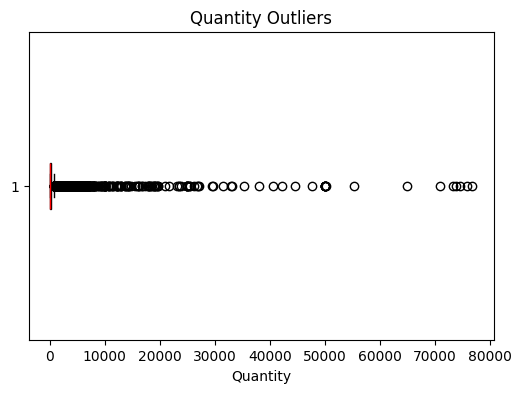

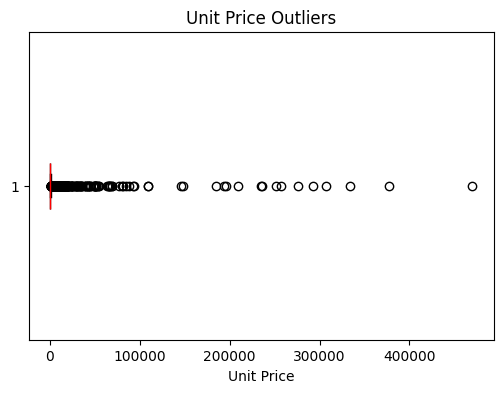

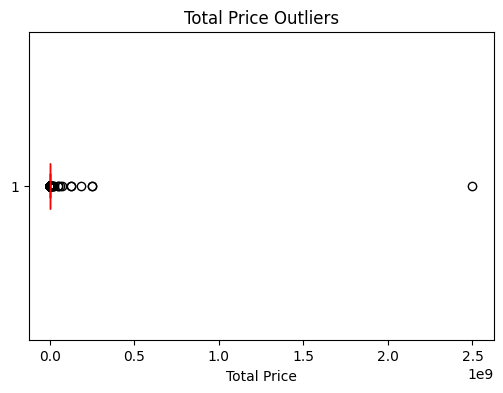

In [49]:
plt.figure(figsize=(6,4))
plt.boxplot(f_data['quantity'].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red'))
plt.title("Quantity Outliers")
plt.xlabel("Quantity")
plt.show()


# Boxplot for Unit Price
plt.figure(figsize=(6,4))
plt.boxplot(f_data['unit_price'].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='red'))
plt.title("Unit Price Outliers")
plt.xlabel("Unit Price")
plt.show()


# Boxplot for Total Price
plt.figure(figsize=(6,4))
plt.boxplot(f_data['total_price'].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightyellow', color='black'),
            medianprops=dict(color='red'))
plt.title("Total Price Outliers")
plt.xlabel("Total Price")
plt.show()


In [50]:
f_data['total'] = f_data['quantity'] * f_data['unit_price']

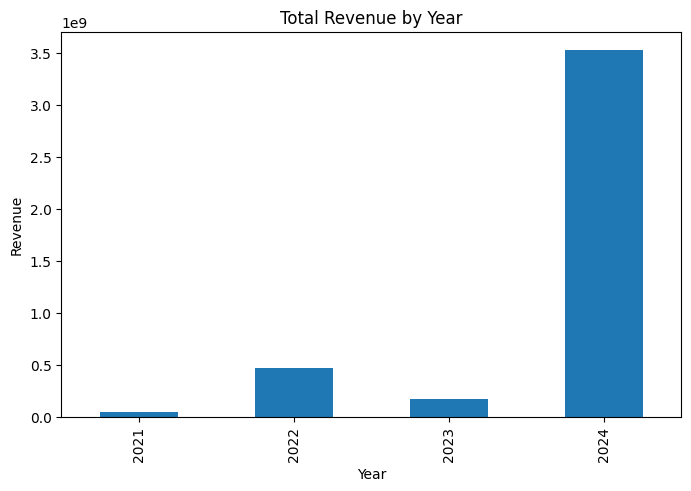

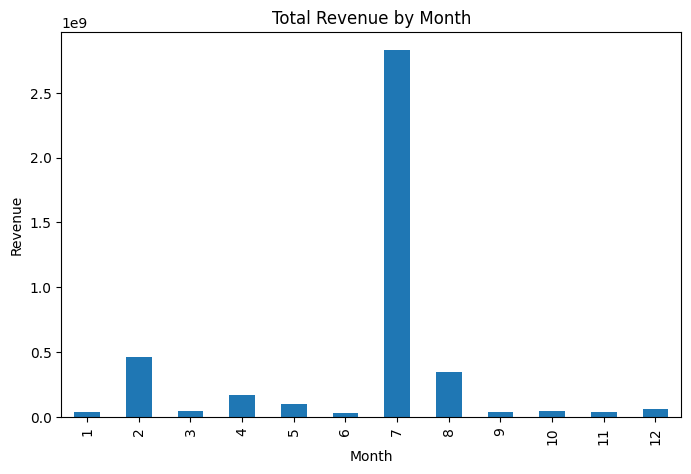

In [51]:
f_data.groupby('year')['total'].sum().plot(kind='bar', figsize=(8,5))
plt.title("Total Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

f_data.groupby('month')['total'].sum().plot(kind='bar', figsize=(8,5))
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


In [52]:
# Select only numeric columns
numeric_cols = f_data.select_dtypes(include=['float64','int64']).columns

# Compute stats
stats = pd.DataFrame({
    'std_dev': f_data[numeric_cols].std(),
    'skewness': f_data[numeric_cols].skew(),
    'kurtosis': f_data[numeric_cols].kurt()
})

print(stats)

                  std_dev    skewness      kurtosis
year         9.994703e-01    0.017164     -1.060911
month        3.407229e+00    0.006941     -1.181649
day          8.627310e+00    0.004498     -1.169222
day_of_week  2.006558e+00    0.009318     -1.259730
hour         6.934985e+00    0.016181     -1.210292
month_index  1.113864e+01    0.073365     -1.090926
quantity     2.427381e+03   18.742341    447.931030
unit_price   8.721053e+03   30.984340   1178.189296
total_price  1.881846e+07  128.905511  17081.704271
total        1.881897e+07  128.901974  17080.767064


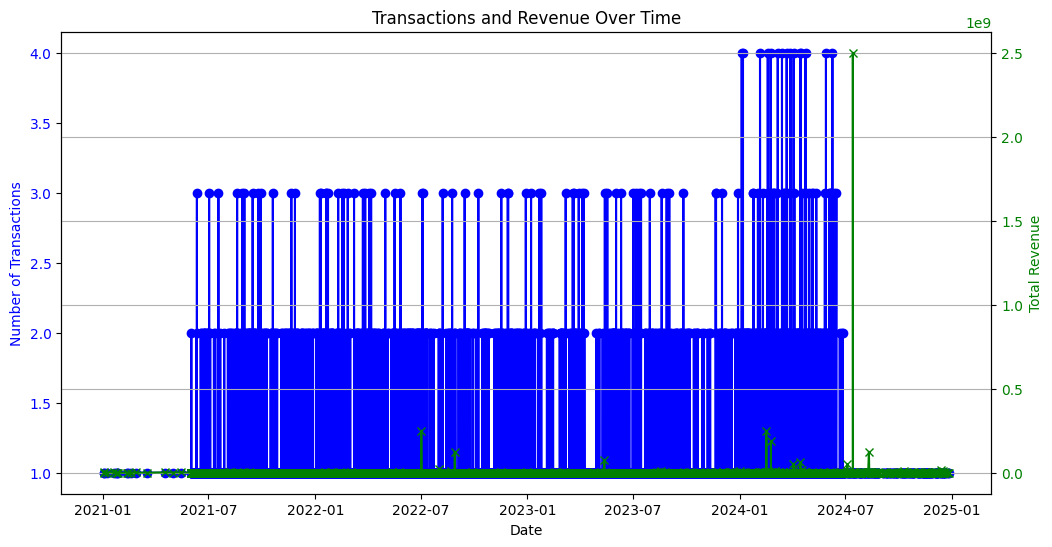

In [53]:
# Aggregate by date
daily_counts = f_data.groupby('date').size()
daily_revenue = f_data.groupby('date')['total'].sum()

fig, ax1 = plt.subplots(figsize=(12,6))

# Plot transaction counts
ax1.plot(daily_counts.index, daily_counts.values, color='blue', marker='o', label='Transactions')
ax1.set_xlabel("Date")
ax1.set_ylabel("Number of Transactions", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot revenue on secondary axis
ax2 = ax1.twinx()
ax2.plot(daily_revenue.index, daily_revenue.values, color='green', marker='x', label='Revenue')
ax2.set_ylabel("Total Revenue", color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title("Transactions and Revenue Over Time")
plt.grid(True)
plt.show()

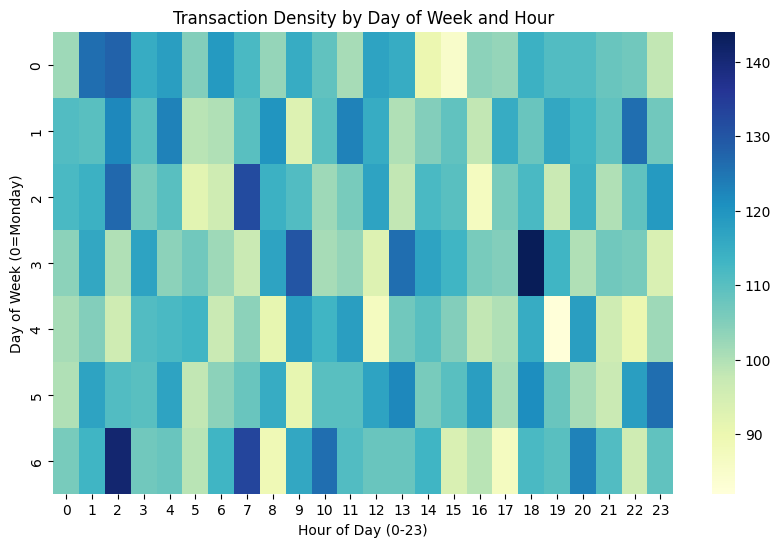

In [54]:
import seaborn as sns
import pandas as pd

# Create pivot table: counts by day_of_week and hour
heatmap_data = f_data.groupby(['day_of_week','hour']).size().unstack(fill_value=0)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Transaction Density by Day of Week and Hour")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Day of Week (0=Monday)")
plt.show()

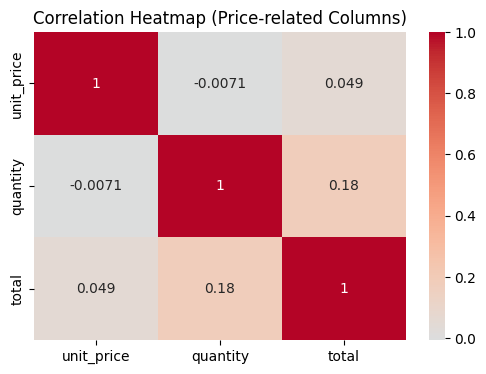

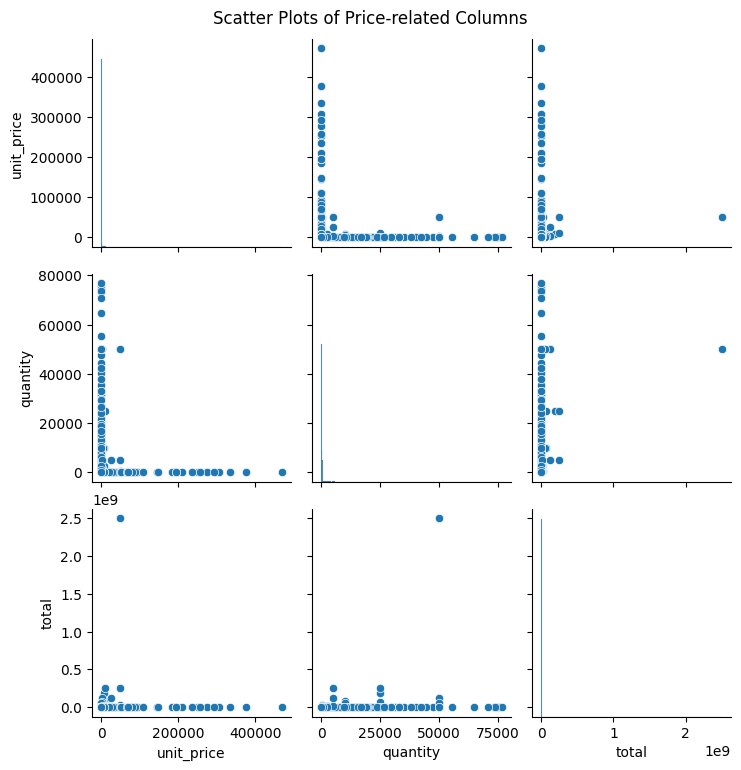

In [55]:
# --- Step 1: Make sure total exists ---
if 'total' not in f_data.columns:
    f_data['total'] = f_data['quantity'] * f_data['unit_price']

# --- Step 2: Select price-related columns ---
price_cols = ['unit_price', 'quantity', 'total']
price_data = f_data[price_cols]

# --- Step 3: Correlation matrix ---
corr_matrix = price_data.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Price-related Columns)")
plt.show()

# --- Step 4: Scatter plots for pairwise relationships ---
sns.pairplot(price_data, diag_kind='hist')
plt.suptitle("Scatter Plots of Price-related Columns", y=1.02)
plt.show()

In [56]:
import pickle
import pandas as pd
import numpy as np

with open("fraud_artifacts.pkl", "rb") as f:
    artifacts = pickle.load(f)

f_data = artifacts['f_data']
consensus = artifacts['consensus']
feature_cols = artifacts['feature_cols']

print("Artifacts loaded successfully.")

Artifacts loaded successfully.


In [57]:
print("Isolation Forest:", f_data['is_anomaly'].sum())
print("Autoencoder:", f_data['ae_anomaly'].sum())
print("HBOS:", f_data['hbos_anomaly'].sum())
print("COPOD:", f_data['copod_anomaly'].sum())

print("Consensus:", len(consensus))

Isolation Forest: 1412
Autoencoder: 1278
HBOS: 1278
COPOD: 1278
Consensus: 472


In [58]:
f_data['ensemble_votes'] = (
    f_data['is_anomaly'].astype(int)
    + f_data['ae_anomaly'].astype(int)
    + f_data['hbos_anomaly'].astype(int)
    + f_data['copod_anomaly'].astype(int)
)

f_data['ensemble_votes'].value_counts().sort_index()

ensemble_votes
0    15847
1      968
2      499
3      464
4      472
Name: count, dtype: int64

In [59]:
consensus['anomaly_type'].value_counts()

anomaly_type
Duplicate              194
Statistical Outlier    145
Behavioral              93
Integrity Mismatch      38
Missing Amount           2
Name: count, dtype: int64

<Axes: xlabel='anomaly_type'>

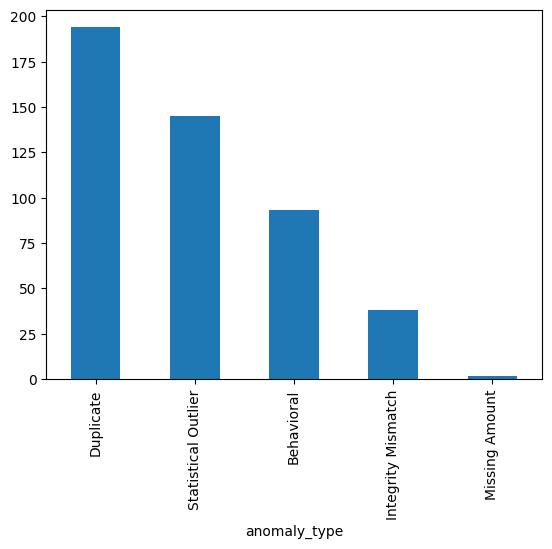

In [60]:
consensus['anomaly_type'].value_counts().plot.bar()

In [61]:
consensus.groupby('vendor_id').size() \
         .sort_values(ascending=False) \
         .head(10)

vendor_id
V1030    33
V1000    20
V1027    20
V1043    14
V1049    14
V1028    13
V1048    13
V1011    13
V1013    12
V1029    12
dtype: int64

In [62]:
consensus.groupby('region').size()

region
APAC     102
EU       116
LATAM    119
UCAN     135
dtype: int64

In [63]:
consensus['category'].value_counts()

category
gloves          104
anesthesia       64
IV_sets          63
syringes         62
monitors         48
oxygen_tanks     48
tubes            43
beds             40
Name: count, dtype: int64

In [64]:
fraud_flags = [
    'is_duplicate_submission',
    'price_mismatch_flag',
    'total_vs_total_price_flag',
    'same_invoice_po_timestamp_diff_amount_flag'
]

for col in fraud_flags:
    print(col)
    print(consensus[col].sum())
    print()

is_duplicate_submission
195

price_mismatch_flag
34

total_vs_total_price_flag
34

same_invoice_po_timestamp_diff_amount_flag
7



In [65]:
print("========== FINAL FINDINGS ==========")
print()

print("Dataset Size:", len(f_data))

print("Isolation Forest Anomalies:",
      f_data['is_anomaly'].sum())

print("Autoencoder Anomalies:",
      f_data['ae_anomaly'].sum())

print("HBOS Anomalies:",
      f_data['hbos_anomaly'].sum())

print("COPOD Anomalies:",
      f_data['copod_anomaly'].sum())

print("Consensus Anomalies:",
      len(consensus))

========== FINAL FINDINGS ==========

Dataset Size: 18250
Isolation Forest Anomalies: 1412
Autoencoder Anomalies: 1278
HBOS Anomalies: 1278
COPOD Anomalies: 1278
Consensus Anomalies: 472
